# Learn the mean of the Lorenz system 

In [1]:
using LorenzParameterEstimation
using Plots
using Random
using Statistics
using LinearAlgebra
gr()
rng = MersenneTwister(7)

MersenneTwister(7)

## Visualisations

In [ ]:
# Initial condition 
u0 = [1.0, 1.0, 1.0]
M  = 20_000
T  = 100.0
dt = T / M
tspan = (0.0, T)
base_params = classic_params()

trajectory = integrate(base_params, u0, (0.0, T), dt)

In [ ]:
# Compute the mean of each coordinate
mean_x = mean(trajectory.u[:, 1])
mean_y = mean(trajectory.u[:, 2])
mean_z = mean(trajectory.u[:, 3])

# 3D trajectory plot with mean point
p1 = plot(trajectory.u[:, 1], trajectory.u[:, 2], trajectory.u[:, 3];
    title="Classic Lorenz (ρ=28.0)", xlabel="X", ylabel="Y", zlabel="Z",
    linecolor=:blue, legend=false, linewidth=2, seriestype=:path3d, size=(600, 400))
scatter!(p1, [mean_x], [mean_y], [mean_z], markersize=8, markercolor=:black, label="Mean")

# XY plane projection with mean point
p2 = plot(trajectory.u[:, 1], trajectory.u[:, 2];
    title="XY Plane", xlabel="X", ylabel="Y",
    linecolor=:red, legend=false, linewidth=0.5)
scatter!(p2, [mean_x], [mean_y], markersize=8, markercolor=:black, label="Mean")

# XZ plane projection with mean point
p3 = plot(trajectory.u[:, 1], trajectory.u[:, 3];
    title="XZ Plane", xlabel="X", ylabel="Z",
    linecolor=:green, legend=false, linewidth=0.5)
scatter!(p3, [mean_x], [mean_z], markersize=8, markercolor=:black, label="Mean")

# YZ plane projection with mean point
p4 = plot(trajectory.u[:, 2], trajectory.u[:, 3];
    title="YZ Plane", xlabel="Y", ylabel="Z",
    linecolor=:orange, legend=false, linewidth=0.5)
scatter!(p4, [mean_y], [mean_z], markersize=8, markercolor=:black, label="Mean")

# Combine all plots in a 2x2 grid
plot(p1, p2, p3, p4, layout=(2,2), size=(1000, 800))


In [ ]:
"""anim = @animate for i in 1:100:M
    plot(trajectory.u[1:i, 1], trajectory.u[1:i, 2], trajectory.u[1:i, 3];
        title="Lorenz Trajectory Evolution", xlabel="X", ylabel="Y", zlabel="Z",
        linecolor=:blue, legend=false, linewidth=1, seriestype=:path3d, size=(600, 400))
end
gif(anim, "img/lorenz_evolution.gif", fps=1)"""

## Test try

In [2]:
# Initial condition 
u0 = [1.0, 1.0, 1.0]
M  = 20_000
T  = 100.0
dt = T / M
tspan = (0.0, T)
base_params = classic_params()

trajectory = integrate(base_params, u0, (0.0, T), dt)

L63Solution{Float64, Vector{Float64}, Matrix{Float64}, L63System{Float64, Vector{Float64}}}([0.0, 0.005, 0.01, 0.015, 0.02, 0.025, 0.03, 0.035, 0.04, 0.045  …  99.955, 99.96000000000001, 99.965, 99.97, 99.97500000000001, 99.98, 99.985, 99.99000000000001, 99.995, 100.0], [1.0 1.0 1.0; 1.0031933311430772 1.129839801362649 0.9920510551862709; … ; -0.9938824148762829 -1.892609128103656 16.965693824136157; -1.0388569689855993 -1.9396559790447456 16.750658939956015], L63System{Float64, Vector{Float64}}(L63Parameters{Float64}(10.0, 28.0, 2.6666666666666665, 0.0, 0.0, 0.0, 1.0), [1.0, 1.0, 1.0], (0.0, 100.0), 0.005), [-1.0388569689855993, -1.9396559790447456, 16.750658939956015], true)

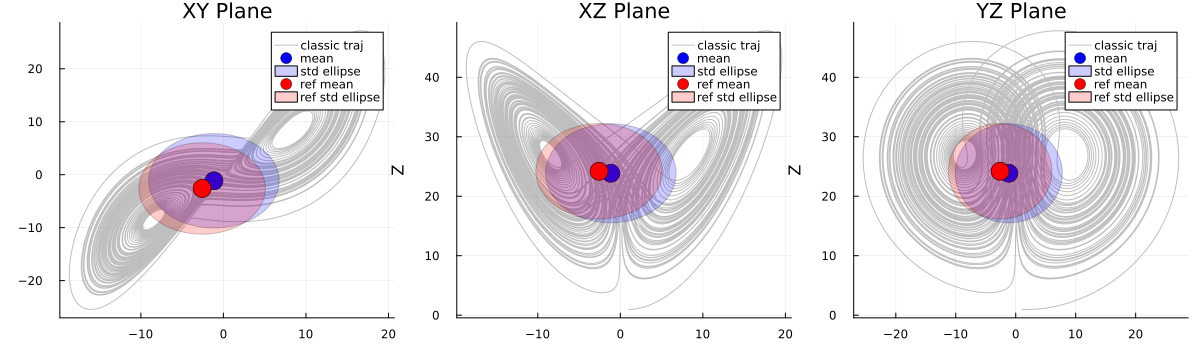

In [3]:
mean_x = mean(trajectory.u[:, 1])
mean_y = mean(trajectory.u[:, 2])
mean_z = mean(trajectory.u[:, 3])

std_x = std(trajectory.u[:, 1])
std_y = std(trajectory.u[:, 2])
std_z = std(trajectory.u[:, 3])

# --- Compare with evaluate_statistics reference ---
ref_stats = evaluate_statistics(base_params; stats=(:mean, :std))
ref_mean = ref_stats.mean
ref_std = ref_stats.std

# XY plane: classic trajectory, mean and std ellipse
p_xy = plot(trajectory.u[:, 1], trajectory.u[:, 2];
    title="XY Plane", xlabel="X", ylabel="Y", linecolor=:gray, alpha=0.5, label="classic traj", legend=:topright)
scatter!(p_xy, [mean_x], [mean_y], markersize=10, markercolor=:blue, label="mean")
ellipse_xy = Shape(
    mean_x .+ std_x * cos.(range(0, 2π, length=100)),
    mean_y .+ std_y * sin.(range(0, 2π, length=100))
)
plot!(p_xy, ellipse_xy, opacity=0.2, color=:blue, label="std ellipse")
scatter!(p_xy, [ref_mean[1]], [ref_mean[2]], markersize=10, markercolor=:red, label="ref mean")
ellipse_xy_ref = Shape(
    ref_mean[1] .+ ref_std[1] * cos.(range(0, 2π, length=100)),
    ref_mean[2] .+ ref_std[2] * sin.(range(0, 2π, length=100))
)
plot!(p_xy, ellipse_xy_ref, opacity=0.2, color=:red, label="ref std ellipse")

# XZ plane: classic trajectory, mean and std ellipse
p_xz = plot(trajectory.u[:, 1], trajectory.u[:, 3];
    title="XZ Plane", xlabel="X", ylabel="Z", linecolor=:gray, alpha=0.5, label="classic traj", legend=:topright)
scatter!(p_xz, [mean_x], [mean_z], markersize=10, markercolor=:blue, label="mean")
ellipse_xz = Shape(
    mean_x .+ std_x * cos.(range(0, 2π, length=100)),
    mean_z .+ std_z * sin.(range(0, 2π, length=100))
)
plot!(p_xz, ellipse_xz, opacity=0.2, color=:blue, label="std ellipse")
scatter!(p_xz, [ref_mean[1]], [ref_mean[3]], markersize=10, markercolor=:red, label="ref mean")
ellipse_xz_ref = Shape(
    ref_mean[1] .+ ref_std[1] * cos.(range(0, 2π, length=100)),
    ref_mean[3] .+ ref_std[3] * sin.(range(0, 2π, length=100))
)
plot!(p_xz, ellipse_xz_ref, opacity=0.2, color=:red, label="ref std ellipse")

# YZ plane: classic trajectory, mean and std ellipse
p_yz = plot(trajectory.u[:, 2], trajectory.u[:, 3];
    title="YZ Plane", xlabel="Y", ylabel="Z", linecolor=:gray, alpha=0.5, label="classic traj", legend=:topright)
scatter!(p_yz, [mean_y], [mean_z], markersize=10, markercolor=:blue, label="mean")
ellipse_yz = Shape(
    mean_y .+ std_y * cos.(range(0, 2π, length=100)),
    mean_z .+ std_z * sin.(range(0, 2π, length=100))
)
plot!(p_yz, ellipse_yz, opacity=0.2, color=:blue, label="std ellipse")
scatter!(p_yz, [ref_mean[2]], [ref_mean[3]], markersize=10, markercolor=:red, label="ref mean")
ellipse_yz_ref = Shape(
    ref_mean[2] .+ ref_std[2] * cos.(range(0, 2π, length=100)),
    ref_mean[3] .+ ref_std[3] * sin.(range(0, 2π, length=100))
)
plot!(p_yz, ellipse_yz_ref, opacity=0.2, color=:red, label="ref std ellipse")

plot(p_xy, p_xz, p_yz, layout=(1,3), size=(1200, 350))

In [4]:
init = L63Parameters(10.0, 28.0, 8/3, 2.0, 0.0, 0.0, 1.0)  # same σ,ρ,β but x shift = 2


L63Parameters{Float64}(10.0, 28.0, 2.6666666666666665, 2.0, 0.0, 0.0, 1.0)

In [ ]:
# Target "true" parameters/statistics — here we assume the classic Lorenz63 mean stats
base_stats = evaluate_statistics(base_params; stats=(:mean,))

# Train to recover the no-shift attractor means
result = train_climate(
    init;
    target_stats=base_stats,
    stats=(:mean,),
    cfg=ClimateConfig(dt=0.01, steps=4000, samples_per_epoch=256),
    base_u0=[1.0, 1.0, 1.0],
    optimizer=Optimisers.Adam(1e-3),
    update_mask=(σ=false, ρ=false, β=false, x_s=true, y_s=false, z_s=false, θ=false),
    epochs=200,
    verbose=true
)

# Results
println("\nFinal parameters:")
@show result.params

println("\nFinal statistics:")
@show result.final_statistics

# Plot loss history
plot(result.loss_history, xlabel="epoch", ylabel="loss", yscale=:log10, legend=false)